In [39]:
# 내 구글 드라이브를 코랩에 연결하기 (권한 허용 창이 뜨면 허용해 주세요)
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
# 그래프에 한글이 깨지지 않도록 나눔고딕 폰트를 설치합니다.
# (실행 후 그래프의 한글이 네모(□)로 보이면, 이 셀을 한 번 더 실행하거나 런타임을 재시작하세요)
!sudo apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 부호 깨짐 방지
print("한글 폰트 설정 완료")


한글 폰트 설정 완료


In [41]:
# 실습에 사용할 라이브러리 불러오기
import pandas as pd
import seaborn as sns

# 실습 데이터가 들어 있는 구글 드라이브 폴더 경로
# (본인 드라이브에 업로드한 위치에 맞게 수정하세요!)
DATA_PATH = "/content/drive/MyDrive/fintech_internship/과제 실습/전세대출 상품 추천/공공데이터포털 데이터/국토부 피처 추가/"


# **데이터 불러오기**

In [42]:
# 인사 데이터 불러오기
df_hr = pd.read_excel(DATA_PATH + "최종_전세보증대위변제현황_피처완료.xlsx")

print("데이터 크기 (행, 열):", df_hr.shape)
df_hr.head(10)

데이터 크기 (행, 열): (50054, 19)


,일련번호,보증완료월,주택가액,임대보증금액,선순위채권금액,대위변제여부,시도,주택구분,전세가율,주택유형위험도,시세_평균전세보증금,시세대비보증금비율,월세전환비율,평균보증금인상률,갱신계약비율,갱신요구권행사비율,평균건축연도,평균전용면적,거래량
0,1,2024-01-01,900000000,130000000,14000000,0,강원,다가구주택,0.1444,0.1782,7.265881e+07,1.789184,0.752305,0.026603,0.038431,0.291667,2009.318080,40.708399,1627
1,1100,2024-11-01,161000000,75000000,86000000,0,강원,다세대주택,0.4658,0.3029,8.145161e+07,0.920792,0.586667,0.000000,0.013514,0.000000,2002.226667,54.432115,75
2,3,2024-08-01,48000000,46080000,0,0,강원,다세대주택,0.9600,0.3029,1.231908e+08,0.374054,0.600000,0.044118,0.043956,0.000000,2003.578947,54.746709,95
3,4,2024-11-01,179000000,157520000,0,0,강원,다세대주택,0.8800,0.3029,8.145161e+07,1.933909,0.586667,0.000000,0.013514,0.000000,2002.226667,54.432115,75
4,5,2023-10-01,161000000,130000000,27780000,0,강원,다세대주택,0.8075,0.3029,1.013526e+08,1.282650,0.530864,0.066667,0.046512,0.500000,1998.790123,60.821138,81
5,6,2023-07-01,189000000,45000000,83520000,0,강원,다세대주택,0.2381,0.3029,1.160128e+08,0.387888,0.635514,0.043333,0.080645,0.200000,2002.093458,54.960129,107
6,1101,2023-02-01,725000000,50000000,363250000,0,강원,다중주택,0.0690,0.0957,7.986527e+07,0.626054,0.765449,0.364763,0.041965,0.219512,2009.388889,44.652302,1424
7,3100,2023-06-01,259000000,220000000,150000,0,강원,단독주택,0.8494,0.0056,8.632876e+07,2.548398,0.759651,0.096627,0.035593,0.238095,2008.911932,52.822202,803
8,4100,2023-04-01,180000000,54000000,0,0,강원,단독주택,0.3000,0.0056,9.282065e+07,0.581767,0.779112,-0.053242,0.040752,0.269231,2007.783784,53.877224,833
9,5100,2024-03-01,117000000,65520000,0,0,강원,단독주택,0.5600,0.0056,8.366450e+07,0.783128,0.773389,-0.047418,0.038420,0.166667,2006.122024,49.087566,962


# **데이터 전처리**

## 결측치 처리

In [43]:
print(df_hr.isna().sum())


일련번호          0
보증완료월         0
주택가액          0
임대보증금액        0
선순위채권금액       0
대위변제여부        0
시도            0
주택구분          0
전세가율          0
주택유형위험도       0
시세_평균전세보증금    0
시세대비보증금비율     0
월세전환비율        0
평균보증금인상률      0
갱신계약비율        0
갱신요구권행사비율     0
평균건축연도        0
평균전용면적        0
거래량           0
dtype: int64


## 불필요한 행 제거

In [44]:
df_hr = df_hr.drop(columns=['일련번호'])
print(df_hr.columns.tolist())


['보증완료월', '주택가액', '임대보증금액', '선순위채권금액', '대위변제여부', '시도', '주택구분', '전세가율', '주택유형위험도', '시세_평균전세보증금', '시세대비보증금비율', '월세전환비율', '평균보증금인상률', '갱신계약비율', '갱신요구권행사비율', '평균건축연도', '평균전용면적', '거래량']


## 원 핫 인코딩

In [45]:
df_hr = pd.get_dummies(df_hr,
    columns=['시도', '주택구분'], drop_first=True)

df_hr.head()


,보증완료월,주택가액,임대보증금액,선순위채권금액,대위변제여부,전세가율,주택유형위험도,시세_평균전세보증금,시세대비보증금비율,월세전환비율,...,시도_제주,시도_충남,시도_충북,주택구분_다세대주택,주택구분_다중주택,주택구분_단독주택,주택구분_아파트,주택구분_연립주택,주택구분_오피스텔,주택구분_주상복합
0,2024-01-01,900000000,130000000,14000000,0,0.1444,0.1782,7.265881e+07,1.789184,0.752305,...,False,False,False,False,False,False,False,False,False,False
1,2024-11-01,161000000,75000000,86000000,0,0.4658,0.3029,8.145161e+07,0.920792,0.586667,...,False,False,False,True,False,False,False,False,False,False
2,2024-08-01,48000000,46080000,0,0,0.9600,0.3029,1.231908e+08,0.374054,0.600000,...,False,False,False,True,False,False,False,False,False,False
3,2024-11-01,179000000,157520000,0,0,0.8800,0.3029,8.145161e+07,1.933909,0.586667,...,False,False,False,True,False,False,False,False,False,False
4,2023-10-01,161000000,130000000,27780000,0,0.8075,0.3029,1.013526e+08,1.282650,0.530864,...,False,False,False,True,False,False,False,False,False,False


## 날짜 - 숫자 변환

In [ ]:
# [수정] 날짜를 하나의 큰 정수(toordinal)로 뭉개면 모델이 '연도가 오를수록 위험도 증가' 같은
# 선형적인 추세만 배우게 됩니다. 연/월로 나누면 '몇 월'처럼 계절성 패턴도 따로 학습할 수 있습니다.
if '보증완료월' in df_hr.columns:
    df_hr['보증완료월'] = pd.to_datetime(df_hr['보증완료월'])
    df_hr['보증완료_연도'] = df_hr['보증완료월'].dt.year
    df_hr['보증완료_월'] = df_hr['보증완료월'].dt.month
    df_hr = df_hr.drop(columns=['보증완료월'])

print(df_hr[['보증완료_연도', '보증완료_월']].head())


# **예측 모델 비교**

## 문제 매물 비율 확인

In [47]:
# 대위변제 비율 = 대위변제여부(0/1)의 평균
print("대위변제 비율:", round(df_hr['대위변제여부'].mean(), 3))


대위변제 비율: 0.075


## 데이터 분할 & K-Fold 실행


In [ ]:
# x = 대위변제여부를 뺀 나머지, y = 대위변제여부
x_hr = df_hr.drop(columns='대위변제여부')
y_hr = df_hr['대위변제여부']

from sklearn.model_selection import train_test_split

# [수정] stratify=y_hr 추가: 대위변제 비율(7.5%)이 train/test 양쪽에 동일하게 유지되도록 함
x_train_hr, x_test_hr, y_train_hr, y_test_hr = train_test_split(
    x_hr, y_hr, test_size=0.2, random_state=1, stratify=y_hr)

print("Train:", x_train_hr.shape, " Test:", x_test_hr.shape)
print("Train 대위변제 비율:", round(y_train_hr.mean(), 4),
      " Test 대위변제 비율:", round(y_test_hr.mean(), 4))


## 수치형 피처 스케일링


In [ ]:
# [추가] 로지스틱회귀는 피처 간 '단위/스케일' 차이에 민감합니다.
# 주택가액(수억 단위)과 전세가율(0~1)이 그대로 같이 들어가면, 로지스틱회귀는 사실상
# 주택가액 같은 큰 값 위주로만 학습하게 됩니다. StandardScaler로 평균 0, 분산 1로 맞춰줍니다.
# (원-핫 인코딩된 시도/주택구분 더미(0/1) 컬럼은 스케일링 대상에서 제외)

from sklearn.preprocessing import StandardScaler

dummy_cols = [c for c in x_hr.columns if c.startswith('시도_') or c.startswith('주택구분_')]
numeric_cols = [c for c in x_hr.columns if c not in dummy_cols]

# 반드시 train으로만 fit하고, test는 transform만 함 (test 정보가 학습에 새어들어가지 않도록)
scaler = StandardScaler()
x_train_hr = x_train_hr.copy()
x_test_hr = x_test_hr.copy()
x_train_hr[numeric_cols] = scaler.fit_transform(x_train_hr[numeric_cols])
x_test_hr[numeric_cols] = scaler.transform(x_test_hr[numeric_cols])

print("스케일링된 수치형 컬럼 수:", len(numeric_cols))
x_train_hr[numeric_cols].describe().loc[['mean', 'std']].round(2)


## 클래스 불균형 보정

불균형(7.5%)을 보정하는 방법은 크게 두 가지가 있습니다.

- **A. 언더샘플링**: train에서 다수 클래스(정상)를 소수 클래스(대위변제) 개수만큼 줄여서 1:1로 맞춤
- **B. class_weight / scale_pos_weight**: 데이터는 그대로 두고, 소수 클래스의 손실(loss)에
  더 큰 가중치를 줘서 모델이 소수 클래스를 무시하지 못하게 함

아래에서 둘 다 실험해보고 비교합니다. (test셋은 두 경우 모두 원래 분포 그대로 유지 — 실제
운영 환경과 같은 조건에서 평가해야 하기 때문에 test는 절대 손대지 않습니다)


In [ ]:
# A. 언더샘플링: train에서만 정상:대위변제를 1:1로 맞춤
train_full = pd.concat([x_train_hr, y_train_hr], axis=1)
minority = train_full[train_full['대위변제여부'] == 1]
majority = train_full[train_full['대위변제여부'] == 0].sample(n=len(minority), random_state=1)
train_bal = pd.concat([minority, majority]).sample(frac=1, random_state=1).reset_index(drop=True)

x_train_bal = train_bal.drop(columns='대위변제여부')
y_train_bal = train_bal['대위변제여부']

print("언더샘플링 후 Train:", x_train_bal.shape, "클래스 비율:", y_train_bal.mean())


In [49]:
# K-Fold 교차검증 (분류는 StratifiedKFold: 각 조각의 대위변제 비율을 똑같이 유지)
from sklearn.model_selection import cross_val_score, StratifiedKFold
import lightgbm as lgb

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
scores = cross_val_score(lgb.LGBMClassifier(random_state=1, verbose=-1),
                         x_hr, y_hr, cv=skfold, scoring='f1')

print("5번의 F1 점수:", scores.round(3))
print("평균 F1:", scores.mean().round(3))


5번의 F1 점수: [0.51  0.497 0.478 0.491 0.486]
평균 F1: 0.492


## 다양한 예측 모델 비교

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

# ① 로지스틱회귀 — 분류의 기준 모델 (선형회귀의 분류 버전)
# [수정] class_weight='balanced' 추가 + 스케일링된 x_train_hr 사용
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression(max_iter=2000, class_weight='balanced')
logit.fit(x_train_hr, y_train_hr)
proba_logit = logit.predict_proba(x_test_hr)[:, 1]
f1_logit = f1_score(y_test_hr, logit.predict(x_test_hr))
auc_logit = roc_auc_score(y_test_hr, proba_logit)
ap_logit = average_precision_score(y_test_hr, proba_logit)
print(f"로지스틱회귀 F1: {f1_logit:.3f}  AUC: {auc_logit:.3f}  PR-AUC: {ap_logit:.3f}")


In [ ]:
# ② 결정트리
# [수정] class_weight='balanced' 추가
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(max_depth=3, random_state=1, class_weight='balanced')
dtc.fit(x_train_hr, y_train_hr)
proba_dtc = dtc.predict_proba(x_test_hr)[:, 1]
f1_dtc = f1_score(y_test_hr, dtc.predict(x_test_hr))
auc_dtc = roc_auc_score(y_test_hr, proba_dtc)
ap_dtc = average_precision_score(y_test_hr, proba_dtc)
print(f"결정트리 F1: {f1_dtc:.3f}  AUC: {auc_dtc:.3f}  PR-AUC: {ap_dtc:.3f}")


In [ ]:
# ③ 랜덤포레스트
# [수정] class_weight='balanced' 추가
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(random_state=1, class_weight='balanced')
rfc.fit(x_train_hr, y_train_hr)
proba_rfc = rfc.predict_proba(x_test_hr)[:, 1]
f1_rfc = f1_score(y_test_hr, rfc.predict(x_test_hr))
auc_rfc = roc_auc_score(y_test_hr, proba_rfc)
ap_rfc = average_precision_score(y_test_hr, proba_rfc)
print(f"랜덤포레스트 F1: {f1_rfc:.3f}  AUC: {auc_rfc:.3f}  PR-AUC: {ap_rfc:.3f}")


In [ ]:
# ④ LGBM
# [수정] scale_pos_weight 추가 (= 정상 개수 / 대위변제 개수 비율만큼 소수 클래스 가중치를 높임)
lgbm_hr = lgb.LGBMClassifier(
    random_state=1, verbose=-1,
    scale_pos_weight=len(y_hr[y_hr == 0]) / len(y_hr[y_hr == 1])
)
lgbm_hr.fit(x_train_hr, y_train_hr)
proba_lgbm = lgbm_hr.predict_proba(x_test_hr)[:, 1]
f1_lgbm = f1_score(y_test_hr, lgbm_hr.predict(x_test_hr))
auc_lgbm = roc_auc_score(y_test_hr, proba_lgbm)
ap_lgbm = average_precision_score(y_test_hr, proba_lgbm)
print(f"LGBM F1: {f1_lgbm:.3f}  AUC: {auc_lgbm:.3f}  PR-AUC: {ap_lgbm:.3f}")


In [ ]:
# 네 모델 F1 / AUC / PR-AUC 비교
# [수정] F1만으로는 임계값(0.5)에 따라 흔들릴 수 있어서, 임계값에 무관한 AUC·PR-AUC를 같이 본다.
# 불균형이 심한 데이터(대위변제 7.5%)에서는 ROC-AUC보다 PR-AUC가 더 보수적이고 정직한 지표다.
비교표 = pd.DataFrame({
    '모델': ['로지스틱회귀', '결정트리', '랜덤포레스트', 'LGBM'],
    'F1 점수': [f1_logit, f1_dtc, f1_rfc, f1_lgbm],
    'AUC': [auc_logit, auc_dtc, auc_rfc, auc_lgbm],
    'PR-AUC': [ap_logit, ap_dtc, ap_rfc, ap_lgbm],
}).sort_values('AUC', ascending=False)

print(비교표.to_string(index=False))


## ROC curve / Precision-Recall curve 비교


In [ ]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

models_proba = {
    '로지스틱회귀': proba_logit,
    '결정트리': proba_dtc,
    '랜덤포레스트': proba_rfc,
    'LGBM': proba_lgbm,
}

for name, proba in models_proba.items():
    RocCurveDisplay.from_predictions(y_test_hr, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test_hr, proba, name=name, ax=axes[1])

axes[0].set_title('ROC Curve')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()


## 부록: 언더샘플링(A) vs class_weight(B) 비교

위 4개 모델은 전부 **B(class_weight/scale_pos_weight)** 방식으로 학습했습니다. 그 이유를
**A(언더샘플링)** 방식과 실제로 비교해서 설명합니다.


In [ ]:
# A 방식(언더샘플링된 x_train_bal/y_train_bal)으로 같은 4개 모델을 다시 학습해서 비교
logit_a = LogisticRegression(max_iter=2000).fit(x_train_bal, y_train_bal)
dtc_a = DecisionTreeClassifier(max_depth=3, random_state=1).fit(x_train_bal, y_train_bal)
rfc_a = RandomForestClassifier(random_state=1).fit(x_train_bal, y_train_bal)
lgbm_a = lgb.LGBMClassifier(random_state=1, verbose=-1).fit(x_train_bal, y_train_bal)

비교_A_vs_B = pd.DataFrame({
    '모델': ['로지스틱회귀', '결정트리', '랜덤포레스트', 'LGBM'],
    'A. 언더샘플링 F1': [
        f1_score(y_test_hr, logit_a.predict(x_test_hr)),
        f1_score(y_test_hr, dtc_a.predict(x_test_hr)),
        f1_score(y_test_hr, rfc_a.predict(x_test_hr)),
        f1_score(y_test_hr, lgbm_a.predict(x_test_hr)),
    ],
    'B. class_weight F1': [f1_logit, f1_dtc, f1_rfc, f1_lgbm],
})
print(비교_A_vs_B.to_string(index=False))

# [참고] 로컬에서 미리 검증한 결과 (시드/라이브러리 버전에 따라 소폭 달라질 수 있음):
#   모델          A.언더샘플링   B.class_weight
#   로지스틱회귀     0.320         0.325
#   결정트리        0.373         0.385
#   랜덤포레스트     0.389         0.492   <- B가 훨씬 좋음
#   LGBM          0.394         0.440   <- B가 더 좋음
#
# A(언더샘플링)는 train 40,043행 중 다수 클래스를 버려서 약 6,000행만 남기 때문에,
# 트리 계열 모델(랜덤포레스트/LGBM)이 학습할 데이터 자체가 크게 줄어 성능이 오히려 떨어집니다.
# B(class_weight)는 가진 데이터를 다 쓰면서 손실 함수만 보정하기 때문에 더 유리합니다.
# => 이 데이터에서는 B 방식을 채택합니다.


## 성능 평가 지표 — 분류 결과 점수

정확도(Accuracy): 0.94
F1 점수: 0.471


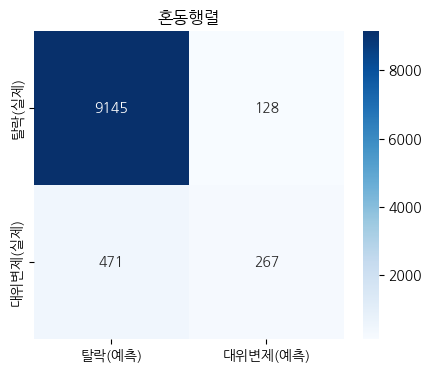

In [55]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

pred_hr = lgbm_hr.predict(x_test_hr)

print("정확도(Accuracy):", round(accuracy_score(y_test_hr, pred_hr), 3))
print("F1 점수:", round(f1_score(y_test_hr, pred_hr), 3))

# 혼동행렬 시각화
cm = confusion_matrix(y_test_hr, pred_hr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['탈락(예측)', '대위변제(예측)'],
            yticklabels=['탈락(실제)', '대위변제(실제)'])
plt.title('혼동행렬')
plt.show()


# **SHAP으로 모델 해석하기**

In [56]:
import shap
shap.initjs()

explainer_hr = shap.TreeExplainer(lgbm_hr)
shap_values_hr = explainer_hr.shap_values(x_train_hr)

print("SHAP 값 계산 완료")


SHAP 값 계산 완료


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


## Force Plot — 매물 1건 해석 (개별 해석 / Local)

In [57]:
# 첫 번째 매물의 대위변제 예측 과정
shap.initjs()
shap.force_plot(explainer_hr.expected_value, shap_values_hr[0], x_train_hr.iloc[0, :])


In [58]:
# 숫자로도 확인
print("[이 매물의 정보]")
print(x_train_hr.iloc[0, :])
print("\n[각 변수의 기여도(SHAP 값)]")
print(pd.Series(shap_values_hr[0], index=x_train_hr.columns).round(3))


[이 매물의 정보]
보증완료월                   738825
주택가액                 925000000
임대보증금액               400000000
선순위채권금액              312250000
전세가율                    0.4324
주택유형위험도                 0.1424
시세_평균전세보증금    262934687.194526
시세대비보증금비율              1.52129
월세전환비율                0.411054
평균보증금인상률             -0.046495
갱신계약비율                0.193124
갱신요구권행사비율             0.361257
평균건축연도             2004.582326
평균전용면적               69.539482
거래량                       3474
시도_경기                    False
시도_경남                    False
시도_경북                    False
시도_광주                    False
시도_대구                    False
시도_대전                    False
시도_부산                    False
시도_서울                    False
시도_세종                    False
시도_울산                    False
시도_인천                     True
시도_전남                    False
시도_전북                    False
시도_제주                    False
시도_충남                    False
시도_충북                    False
주택구분_다세대주택               Fal

## Summary Plot — 전체 변수 중요도 (전체 해석 / Global)

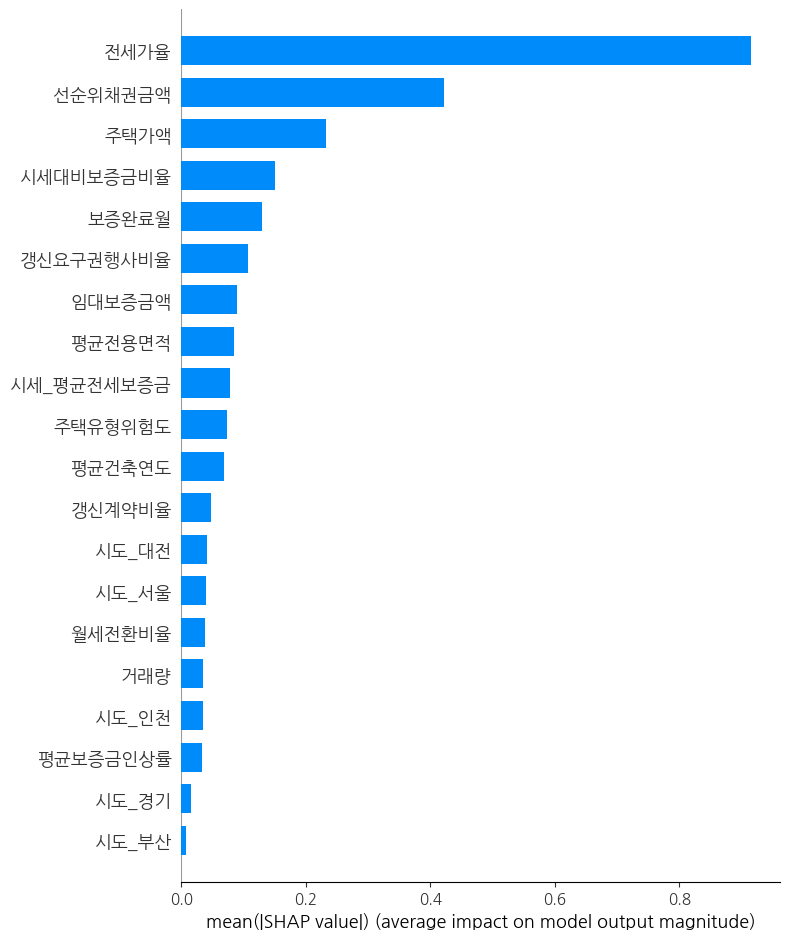

In [59]:
shap.summary_plot(shap_values_hr, x_train_hr, plot_type="bar")
